In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##  1.. Data Collection !

In [3]:
import os
working_directory = os.getcwd()

In [3]:
print(working_directory)

/Users/sameersuman/Documents/StockMarketAnalysis


In [4]:
path = working_directory + '/individual_stocks_5yr/*csv'

In [6]:
import glob

In [7]:
glob.glob(path)

['/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/XRX_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/GS_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/SPGI_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/MTB_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/V_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/CTAS_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/ESRX_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/APH_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/BBT_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/RHI_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/GGP_data.csv',
 '/Users/sameersuman/Documents/S

In [9]:
len(glob.glob(path)) ## total files we have 

505

In [ ]:
# lets store filesof those stock that we have to consider for analysis ..

In [5]:
company_list = [
   working_directory + '/individual_stocks_5yr/AAPL_data.csv' , 
   working_directory + '/individual_stocks_5yr/AMZN_data.csv' , 
   working_directory + '/individual_stocks_5yr/GOOG_data.csv' , 
    working_directory + '/individual_stocks_5yr/MSFT_data.csv'  
]

In [13]:
## use Warnings package to get rid of any future warning ..

import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
## Combine data from multiple sources into a single dataset

In [6]:
all_data = pd.DataFrame()

for file in company_list:
    
    current_df = pd.read_csv(file)

    # The commented line was actually the correct approach
    all_data = pd.concat([current_df, all_data], ignore_index=True)  

In [16]:
all_data.shape ## dimensions of all_data dataframe ..

(4752, 7)

In [17]:
all_data.head() ## top 5 rows of all_data dataframe ..

,date,open,high,low,close,volume,Name
0,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [18]:
all_data['Name'].unique()

array(['MSFT', 'GOOG', 'AMZN', 'AAPL'], dtype=object)

## DATA CLEANING & PREPARATIONS

In [19]:
all_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')

In [20]:
all_data.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

In [7]:
all_data['date'] = pd.to_datetime(all_data['date']) ## convert date column to datetime format ..

In [22]:
all_data.dtypes

date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object

In [23]:
all_data['date']

0      2013-02-08
1      2013-02-11
2      2013-02-12
3      2013-02-13
4      2013-02-14
          ...    
4747   2018-02-01
4748   2018-02-02
4749   2018-02-05
4750   2018-02-06
4751   2018-02-07
Name: date, Length: 4752, dtype: datetime64[ns]

In [24]:
all_data.isnull().sum() ## check for null values in all_data dataframe ..

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [25]:
all_data.duplicated().sum() ## check for duplicate values in all_data dataframe ..

np.int64(0)

In [27]:
df=all_data['volume']<0 ## check for negative values in volume column of all_data dataframe ..

In [28]:
all_data[df] ## display rows where volume is negative ..

,date,open,high,low,close,volume,Name


In [9]:
tech_list = all_data['Name'].unique()

In [30]:
tech_list

array(['MSFT', 'GOOG', 'AMZN', 'AAPL'], dtype=object)

In [8]:
all_data = all_data.sort_values(by=['Name', 'date']) ## sort all_data dataframe by Name and date column in ascending order ..

## EDA
## 2.TIME SERIES ANALYSIS
## Analysing change in price of the stock overtime !

In [32]:
all_data

,date,open,high,low,close,volume,Name
3493,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
3494,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
3495,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3496,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
3497,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
...,...,...,...,...,...,...,...
1254,2018-02-01,94.7900,96.0700,93.5813,94.2600,47227882,MSFT
1255,2018-02-02,93.6400,93.9700,91.5000,91.7800,47867753,MSFT
1256,2018-02-05,90.5600,93.2400,88.0000,88.0000,51031465,MSFT
1257,2018-02-06,86.8900,91.4750,85.2500,91.3300,67998564,MSFT


In [ ]:
## which is the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ?

In [10]:
all_data["daily_return"]=all_data.groupby('Name')['close'].pct_change() ## calculate daily return for each stock by taking percentage change of close price ..


In [37]:
risk = all_data.groupby('Name')['daily_return'].std() ## calculate standard deviation of daily return for each stock to measure volatility ..

In [38]:
risk.sort_values() ## sort risk values in ascending order to find the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ..

Name
GOOG    0.014069
MSFT    0.014210
AAPL    0.014593
AMZN    0.018235
Name: daily_return, dtype: float64

In [40]:
safest_stock = risk.idxmin() ## find the stock with minimum risk value to identify the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ..

In [42]:
safest_stock

'GOOG'

## 3. TOTAL RETURN ANALYSIS
## Which stock made the highest money?

In [100]:
## Calculate total return for each stock (from first day to last day)
total_returns = {}

for stock in tech_list:
    stock_data = all_data[all_data['Name'] == stock].sort_values('date')
    first_price = stock_data['close'].iloc[0]
    last_price = stock_data['close'].iloc[-1]
    total_return = ((last_price - first_price) / first_price) * 100
    total_returns[stock] = total_return

# Display results sorted by total return (highest first)
sorted_returns = sorted(total_returns.items(), key=lambda x: x[1], reverse=True)

print("="*50)
print("TOTAL RETURN BY STOCK (5-Year Period)")
print("="*50)
for stock, return_pct in sorted_returns:
    print(f"{stock}: {return_pct:+.2f}%")

best_stock = sorted_returns[0][0]
best_return = sorted_returns[0][1]
print("="*50)
print(f"\n✓ {best_stock} made the highest money with a {best_return:.2f}% return!")

TOTAL RETURN BY STOCK (5-Year Period)
AMZN: +440.86%
MSFT: +225.26%
AAPL: +135.12%
GOOG: +87.76%

✓ AMZN made the highest money with a 440.86% return!


4.Which stock made the highest money??

In [11]:
all_data["cumulative_return"] = (1+all_data["daily_return"]).groupby(all_data['Name']).cumprod() ## calculate cumulative return for each stock by taking cumulative product of (1 + daily return) for each stock ..

In [102]:
final_returns = all_data.groupby('Name')["cumulative_return"].last() ## get the last value of cumulative return for each stock to find the total cumulative return for each stock over the 5 year period ..

final_returns.sort_values(ascending=False) ## sort final returns in descending order to find the stock with highest cumulative return over the 5 year period ..

Name
AMZN    5.408589
MSFT    3.252632
AAPL    2.351218
GOOG    1.877628
Name: cumulative_return, dtype: float64

In [103]:
best_stock = final_returns.idxmax()
best_stock

'AMZN'

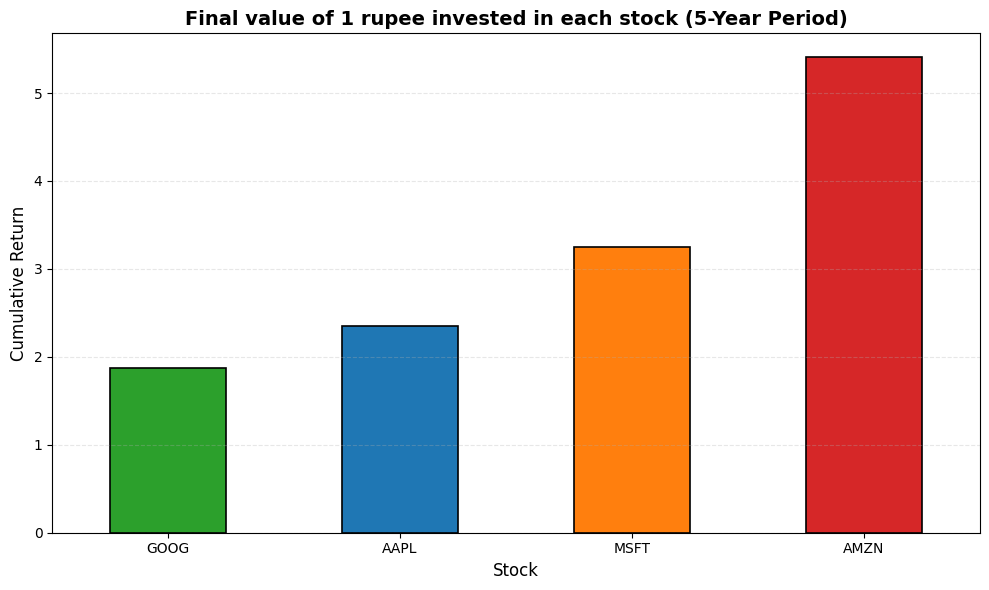

In [104]:
## Plot bar chart of final returns (ascending order)
plt.figure(figsize=(10, 6))
final_returns.sort_values().plot(kind='bar', color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], edgecolor='black', linewidth=1.2)
plt.title('Final value of 1 rupee invested in each stock (5-Year Period)', fontsize=14, fontweight='bold')
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

5. 1 lakh/million SAFE INVESTMENT SIMULATION

In [105]:
best_stock = final_returns.idxmax()
best_stock

'AMZN'

In [106]:
investment = 1000000

In [107]:
df_best = all_data[all_data['Name'] == best_stock]

In [108]:
df_best

,date,open,high,low,close,volume,Name,daily_return,cumulative_return
2234,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN,NaN,NaN
2235,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN,-0.018095,0.981905
2236,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN,0.005793,0.987593
2237,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN,0.041631,1.028708
2238,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN,-0.000854,1.027830
...,...,...,...,...,...,...,...,...,...
3488,2018-02-01,1445.00,1459.88,1385.140,1390.00,9113808,AMZN,-0.041967,5.306356
3489,2018-02-02,1477.39,1498.00,1414.000,1429.95,11125722,AMZN,0.028741,5.458866
3490,2018-02-05,1402.62,1458.98,1320.720,1390.00,11494985,AMZN,-0.027938,5.306356
3491,2018-02-06,1361.46,1443.99,1351.790,1442.84,11066819,AMZN,0.038014,5.508074


In [109]:
df_best['investment_value'] = investment * df_best['cumulative_return'] 
## calculate the value of the initial investment over time by multiplying the initial investment with the cumulative return for each day ..

In [110]:
df_best['investment_value']


2234             NaN
2235    9.819049e+05
2236    9.875931e+05
2237    1.028708e+06
2238    1.027830e+06
            ...     
3488    5.306356e+06
3489    5.458866e+06
3490    5.306356e+06
3491    5.508074e+06
3492    5.408589e+06
Name: investment_value, Length: 1259, dtype: float64

In [111]:
df_best['investment_value'] .tail().values[0] ## get the final value of the initial investment after 5 years by taking the last value of the investment_value column for the best stock ..

np.float64(5306356.174842537)

In [112]:
df_best.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return', 'investment_value'],
      dtype='object')

px.line()

In [113]:
px.line(df_best,  
        x='date', 
        y='investment_value', 
        title=f'1 Million Investment Value Over Time for - {best_stock}', 
        labels={
            'date': 'Date', 
            'investment_value': 'Portfolio Value (₹)'})

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'Date=%{x}<br>Portfolio Value (₹)=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array(['2013-02-08T00:00:00.000000000', '2013-02-11T00:00:00.000000000',
                          '2013-02-12T00:00:00.000000000', ..., '2018-02-05T00:00:00.000000000',
                          '2018-02-06T00:00:00.000000000', '2018-02-07T00:00:00.000000000'],
                         dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAA+H+/iSvjIfctQfkNrhqSIy' ... 'v9PVRBFPrVg/oCVUGtyDpb06FUQQ=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': '1 Million Investment Value Over Time for - AMZN'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Date'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Portfolio Value (₹)'}}}
})

In [114]:
## 6. TOP 5 WORST MARKET CRASHES (Biggest Daily Losses)

In [15]:
## Find top 5 worst days (biggest daily losses) for each stock
print("="*80)
print("TOP 5 WORST MARKET CRASHES - BIGGEST DAILY LOSSES FOR EACH STOCK")
print("="*80)

for stock in tech_list:
    stock_data = all_data[all_data['Name'] == stock].sort_values('date').copy()
    
    # Get top 5 most negative daily returns
    worst_days = stock_data.nsmallest(5, 'daily_return')[['date', 'close', 'daily_return']]
    
    print(f"\n📉 {stock} - TOP 5 WORST TRADING DAYS:")
    print(f"{'-'*76}")
    print(f"{'Rank':<6} {'Date':<12} {'Close Price':<15} {'Daily Loss':<20}")
    print(f"{'-'*76}")
    
    for idx, (i, row) in enumerate(worst_days.iterrows(), 1):
        loss_pct = row['daily_return'] * 100
        print(f"{idx:<6} {str(row['date'].date()):<12} ₹{row['close']:<14.2f} {loss_pct:>7.2f}%")
    
    # Summary stats
    avg_loss = worst_days['daily_return'].mean() * 100
    worst_loss = worst_days['daily_return'].min() * 100
    print(f"{'-'*76}")
    print(f"Average Loss (Top 5 days):  {avg_loss:.2f}%")
    print(f"Worst Single Day Loss:      {worst_loss:.2f}%")
    print()

print("="*80)

TOP 5 WORST MARKET CRASHES - BIGGEST DAILY LOSSES FOR EACH STOCK

📉 AAPL - TOP 5 WORST TRADING DAYS:
----------------------------------------------------------------------------
Rank   Date         Close Price     Daily Loss          
----------------------------------------------------------------------------
1      2014-01-28   ₹72.36            -7.99%
2      2016-01-27   ₹93.42            -6.57%
3      2016-04-27   ₹97.82            -6.26%
4      2015-08-21   ₹105.76           -6.12%
5      2013-04-17   ₹57.54            -5.50%
----------------------------------------------------------------------------
Average Loss (Top 5 days):  -6.49%
Worst Single Day Loss:      -7.99%


📉 AMZN - TOP 5 WORST TRADING DAYS:
----------------------------------------------------------------------------
Rank   Date         Close Price     Daily Loss          
----------------------------------------------------------------------------
1      2014-01-31   ₹358.69          -11.00%
2      2014-04-25   ₹30

In [116]:
all_data[all_data['Name'] == "AAPL"].nsmallest(5, 'daily_return')[['date', 'close', 'daily_return']]

,date,close,daily_return
3736,2014-01-28,72.3571,-0.079927
4239,2016-01-27,93.4200,-0.065707
4302,2016-04-27,97.8200,-0.062578
4131,2015-08-21,105.7600,-0.061163
3539,2013-04-17,57.5428,-0.054993


In [117]:
worst_days =all_data.groupby('Name', group_keys=False).apply(lambda x: x.nsmallest(5, 'daily_return'))

In [118]:
worst_days

,date,open,high,low,close,volume,Name,daily_return,cumulative_return
3736,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,AAPL,-0.079927,1.066361
4239,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,AAPL,-0.065707,1.376775
4302,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,AAPL,-0.062578,1.441620
4131,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,AAPL,-0.061163,1.558636
3539,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,AAPL,-0.054993,0.848036
2480,2014-01-31,371.7600,375.4500,357.7600,358.6900,16181519,AMZN,-0.109972,1.369307
2538,2014-04-25,316.2500,316.4900,302.7100,303.8300,16186737,AMZN,-0.098828,1.159878
2601,2014-07-25,317.3000,324.8700,314.7600,324.0100,17855141,AMZN,-0.096484,1.236915
2665,2014-10-24,284.4000,293.8100,284.0000,287.0600,19805911,AMZN,-0.083403,1.095858
2982,2016-01-29,571.9800,593.0000,570.0000,587.0000,14677550,AMZN,-0.076100,2.240886


In [119]:
worst_days.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return'],
      dtype='object')

In [120]:
worst_days[['date', 'Name', 'daily_return']]

,date,Name,daily_return
3736,2014-01-28,AAPL,-0.079927
4239,2016-01-27,AAPL,-0.065707
4302,2016-04-27,AAPL,-0.062578
4131,2015-08-21,AAPL,-0.061163
3539,2013-04-17,AAPL,-0.054993
2480,2014-01-31,AMZN,-0.109972
2538,2014-04-25,AMZN,-0.098828
2601,2014-07-25,AMZN,-0.096484
2665,2014-10-24,AMZN,-0.083403
2982,2016-01-29,AMZN,-0.076100


In [121]:
worst_days.dtypes

date                 datetime64[ns]
open                        float64
high                        float64
low                         float64
close                       float64
volume                        int64
Name                         object
daily_return                float64
cumulative_return           float64
dtype: object

In [122]:
px.bar( 
       worst_days, 
       x='date', 
       y='daily_return', 
       color='Name', 
       title='Top 5 Worst Trading Days for Each Stock',
       labels={
           'date': 'Date', 
           'daily_return': 'Daily Return (%)'
       },
       hover_data=['close']
       )

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': {'bdata': 'tFn1udoWUkB7FK5H4VpXQBSuR+F6dFhAcT0K16NwWkBoImx4esVMQA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=AAPL<br>Date=%{x}<br>Dail' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'AAPL',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'AAPL',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['2014-01-28T00:00:00.000000000', '2016-01-27T00:00:00.000000000',
                          '2016-04-27T00:00:00.000000000', '2015-08-21T00:00:00.000000000',
                          '2013-04-17T00:00:00.000000000'], dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': 'wLdeJxx2tL+guhpUJdKwvxgz31IaBbC/4Dg5Kr5Qr79Q0cZ1Ciisvw==', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': '16NwPQprdkDhehSuR/1yQFyPwvUoQHRAKVyPwvXwcUAAAAAAAFiCQA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=AMZN<br>Date=%{x}<br>Dail' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'AMZN',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'AMZN',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['2014-01-31T00:00:00.000000000', '2014-04-25T00:00:00.000000000',
                          '2014-07-25T00:00:00.000000000', '2014-10-24T00:00:00.000000000',
                          '2016-01-29T00:00:00.000000000'], dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': '2IFjqycnvL8IzNio0Uy5v7DBq/Qms7i/yB0pB95Ztb9IFaCSRnuzvw==', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': 'XI/C9Sh2hkCkcD0K1yODQDMzMzMzf5BAmpmZmZm3hkCamZmZmV+RQA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=GOOG<br>Date=%{x}<br>Dail' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'GOOG',
              'marker': {'color': '#00cc96', 'pattern': {'shape': ''}},
              'name': 'GOOG',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['2016-04-22T00:00:00.000000000', '2015-08-21T00:00:00.000000000',
                          '2018-02-05T00:00:00.000000000', '2016-02-03T00:00:00.000000000',
                          '2018-02-02T00:00:00.000000000'], dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': 'sPV9nDk6q79gj4/tmDCrv1Do6EQh1am/MN6JZFI+qb9gYo1bcHeovw==', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': 'ZmZmZmZmP0AUrkfhelRFQKRwPQrX40lAKVyPwvWIRUDhehSuR+E/QA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=MSFT<br>Date=%{x}<br>Dail' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'MSFT',
              'marker': {'color': '#ab63fa', 'pattern': {'shape': ''}},
              'name': 'MSFT',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['2013-07-19T00:00:00.000000000', '2015-01-27T00:00:00.000000000',
                          '2016-04-22T00:00:00.000000000', '2015-08-21T00:00:00.000000000',
                          '2013-09-03T00:00:00.000000000'], dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': 'kFlf4c4uvb8g+luTRrC3vxBTKwibW7K/oNGWfeAKrb8QgQkL9Eynvw==', 'dtype': 'f8'},
              'yaxis': 'y'}]

In [123]:
worst_days['crash_label']=worst_days["Name"]+" - "+worst_days['date'].dt.strftime('%Y-%m-%d')

In [124]:
worst_days['crash_label']

3736    AAPL - 2014-01-28
4239    AAPL - 2016-01-27
4302    AAPL - 2016-04-27
4131    AAPL - 2015-08-21
3539    AAPL - 2013-04-17
2480    AMZN - 2014-01-31
2538    AMZN - 2014-04-25
2601    AMZN - 2014-07-25
2665    AMZN - 2014-10-24
2982    AMZN - 2016-01-29
1781    GOOG - 2016-04-22
1613    GOOG - 2015-08-21
2231    GOOG - 2018-02-05
1726    GOOG - 2016-02-03
2230    GOOG - 2018-02-02
111     MSFT - 2013-07-19
494     MSFT - 2015-01-27
806     MSFT - 2016-04-22
638     MSFT - 2015-08-21
142     MSFT - 2013-09-03
Name: crash_label, dtype: object

In [125]:
px.bar( 
       worst_days, 
       x='crash_label', 
       y='daily_return', 
       color='Name', 
       title='Top 5 Worst Trading Days for Each Stock',
       labels={
           'date': 'Date', 
           'daily_return': 'Daily Return (%)'
       },
       hover_data=['close']
       )

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': {'bdata': 'tFn1udoWUkB7FK5H4VpXQBSuR+F6dFhAcT0K16NwWkBoImx4esVMQA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=AAPL<br>crash_label=%{x}<' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'AAPL',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'AAPL',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['AAPL - 2014-01-28', 'AAPL - 2016-01-27', 'AAPL - 2016-04-27',
                          'AAPL - 2015-08-21', 'AAPL - 2013-04-17'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'wLdeJxx2tL+guhpUJdKwvxgz31IaBbC/4Dg5Kr5Qr79Q0cZ1Ciisvw==', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': '16NwPQprdkDhehSuR/1yQFyPwvUoQHRAKVyPwvXwcUAAAAAAAFiCQA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=AMZN<br>crash_label=%{x}<' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'AMZN',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'AMZN',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['AMZN - 2014-01-31', 'AMZN - 2014-04-25', 'AMZN - 2014-07-25',
                          'AMZN - 2014-10-24', 'AMZN - 2016-01-29'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': '2IFjqycnvL8IzNio0Uy5v7DBq/Qms7i/yB0pB95Ztb9IFaCSRnuzvw==', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': 'XI/C9Sh2hkCkcD0K1yODQDMzMzMzf5BAmpmZmZm3hkCamZmZmV+RQA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=GOOG<br>crash_label=%{x}<' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'GOOG',
              'marker': {'color': '#00cc96', 'pattern': {'shape': ''}},
              'name': 'GOOG',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['GOOG - 2016-04-22', 'GOOG - 2015-08-21', 'GOOG - 2018-02-05',
                          'GOOG - 2016-02-03', 'GOOG - 2018-02-02'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'sPV9nDk6q79gj4/tmDCrv1Do6EQh1am/MN6JZFI+qb9gYo1bcHeovw==', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': 'ZmZmZmZmP0AUrkfhelRFQKRwPQrX40lAKVyPwvWIRUDhehSuR+E/QA==',
                             'dtype': 'f8',
                             'shape': '5, 1'},
              'hovertemplate': ('Name=MSFT<br>crash_label=%{x}<' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'MSFT',
              'marker': {'color': '#ab63fa', 'pattern': {'shape': ''}},
              'name': 'MSFT',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['MSFT - 2013-07-19', 'MSFT - 2015-01-27', 'MSFT - 2016-04-22',
                          'MSFT - 2015-08-21', 'MSFT - 2013-09-03'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'kFlf4c4uvb8g+luTRrC3vxBTKwibW7K/oNGWfeAKrb8QgQkL9Eynvw==', 'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'title': {'text': 'Name'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Top 5 Worst Trading Days for Each Stock'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'crash_label'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 

7. Moving average (Trend Analysis)

In [126]:
all_data["close"]

3493    67.8542
3494    68.5614
3495    66.8428
3496    66.7156
3497    66.6556
         ...   
1254    94.2600
1255    91.7800
1256    88.0000
1257    91.3300
1258    89.6100
Name: close, Length: 4752, dtype: float64

In [128]:
## 8. MOVING AVERAGE ANALYSIS (20-Day & 50-Day)

In [12]:
## Calculate 20-day and 50-day moving averages grouped by stock name
all_data['MA_20'] = all_data.groupby('Name')['close'].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
all_data['MA_50'] = all_data.groupby('Name')['close'].transform(lambda x: x.rolling(window=50, min_periods=1).mean())

print("Moving Averages Added Successfully!")
print(f"\nSample of data with Moving Averages:")
print(all_data[['date', 'Name', 'close', 'MA_20', 'MA_50']].tail(10))

Moving Averages Added Successfully!

Sample of data with Moving Averages:
           date  Name  close    MA_20    MA_50
1249 2018-01-25  MSFT  92.33  88.6410  85.9292
1250 2018-01-26  MSFT  94.06  89.0585  86.1318
1251 2018-01-29  MSFT  93.92  89.4685  86.3292
1252 2018-01-30  MSFT  92.74  89.8285  86.5244
1253 2018-01-31  MSFT  95.01  90.2815  86.7606
1254 2018-02-01  MSFT  94.26  90.6770  86.9978
1255 2018-02-02  MSFT  91.78  90.9105  87.1828
1256 2018-02-05  MSFT  88.00  90.9010  87.2684
1257 2018-02-06  MSFT  91.33  91.0535  87.4328
1258 2018-02-07  MSFT  89.61  91.1230  87.5598


In [14]:
## Plot Close Price with 20-day and 50-day Moving Averages for each stock (Interactive with Hover)
from plotly.subplots import make_subplots
import plotly.graph_objects as go

colors_map = {'AAPL': '#1f77b4', 'AMZN': '#ff7f0e', 'GOOG': '#2ca02c', 'MSFT': '#d62728'}
stocks = sorted(tech_list)

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f'{stock} - Price with Moving Averages' for stock in stocks],
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Add traces for each stock
for idx, stock in enumerate(stocks):
    row = (idx // 2) + 1
    col = (idx % 2) + 1
    
    stock_data = all_data[all_data['Name'] == stock].sort_values('date')
    
    # Close Price
    fig.add_trace(
        go.Scatter(
            x=stock_data['date'], 
            y=stock_data['close'],
            name=f'{stock} Close',
            mode='lines',
            line=dict(color=colors_map[stock], width=2),
            hovertemplate='<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>Price: ₹%{y:.2f}<extra></extra>',
            legendgroup=stock,
            showlegend=True
        ),
        row=row, col=col
    )
    
    # 20-Day MA
    fig.add_trace(
        go.Scatter(
            x=stock_data['date'], 
            y=stock_data['MA_20'],
            name=f'{stock} 20-Day MA',
            mode='lines',
            line=dict(color='#FF6B6B', width=2, dash='dash'),
            hovertemplate='<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>MA: ₹%{y:.2f}<extra></extra>',
            legendgroup=stock,
            showlegend=True
        ),
        row=row, col=col
    )
    
    # 50-Day MA
    fig.add_trace(
        go.Scatter(
            x=stock_data['date'], 
            y=stock_data['MA_50'],
            name=f'{stock} 50-Day MA',
            mode='lines',
            line=dict(color='#4ECDC4', width=2, dash='dash'),
            hovertemplate='<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>MA: ₹%{y:.2f}<extra></extra>',
            legendgroup=stock,
            showlegend=True
        ),
        row=row, col=col
    )
    
    # Update axes labels
    fig.update_xaxes(title_text='Date', row=row, col=col)
    fig.update_yaxes(title_text='Price (₹)', row=row, col=col)

# Update layout
fig.update_layout(
    title_text='Stock Price vs 20-Day & 50-Day Moving Averages (Hover for Details)',
    height=900,
    width=1400,
    hovermode='x unified',
    template='plotly_white',
    font=dict(size=11)
)

fig.show()

print("\n" + "="*80)
print("MOVING AVERAGE INSIGHTS")
print("="*80)
for stock in sorted(tech_list):
    stock_data = all_data[all_data['Name'] == stock]
    latest = stock_data.iloc[-1]
    print(f"\n{stock}:")
    print(f"  Current Close:     ₹{latest['close']:.2f}")
    print(f"  20-Day MA:         ₹{latest['MA_20']:.2f}")
    print(f"  50-Day MA:         ₹{latest['MA_50']:.2f}")
    print(f"  Price vs 20-MA:    {((latest['close']/latest['MA_20'] - 1) * 100):+.2f}%")
    print(f"  Price vs 50-MA:    {((latest['close']/latest['MA_50'] - 1) * 100):+.2f}%")
    
    # Signal interpretation
    if latest['close'] > latest['MA_20'] and latest['MA_20'] > latest['MA_50']:
        signal = "🟢 BULLISH (Price > 20-MA > 50-MA)"
    elif latest['close'] < latest['MA_20'] and latest['MA_20'] < latest['MA_50']:
        signal = "🔴 BEARISH (Price < 20-MA < 50-MA)"
    else:
        signal = "🟡 NEUTRAL (Mixed signals)"
    print(f"  Signal:            {signal}")
print("="*80)


MOVING AVERAGE INSIGHTS

AAPL:
  Current Close:     ₹159.54
  20-Day MA:         ₹171.01
  50-Day MA:         ₹171.76
  Price vs 20-MA:    -6.71%
  Price vs 50-MA:    -7.11%
  Signal:            🔴 BEARISH (Price < 20-MA < 50-MA)

AMZN:
  Current Close:     ₹1416.78
  20-Day MA:         ₹1361.36
  50-Day MA:         ₹1253.26
  Price vs 20-MA:    +4.07%
  Price vs 50-MA:    +13.05%
  Signal:            🟢 BULLISH (Price > 20-MA > 50-MA)

GOOG:
  Current Close:     ₹1048.58
  20-Day MA:         ₹1133.07
  50-Day MA:         ₹1084.57
  Price vs 20-MA:    -7.46%
  Price vs 50-MA:    -3.32%
  Signal:            🟡 NEUTRAL (Mixed signals)

MSFT:
  Current Close:     ₹89.61
  20-Day MA:         ₹91.12
  50-Day MA:         ₹87.56
  Price vs 20-MA:    -1.66%
  Price vs 50-MA:    +2.34%
  Signal:            🟡 NEUTRAL (Mixed signals)
